In [1]:
import os
import sys
import numpy as np
import pandas as pd
pd.set_option('display.max_rows', 500)
sys.path.append('../src/')
from nn_utils import Engine, FeedForwardNN, save_fig, seed_everything
from plot_config import SEED, fig_params
from train import eval_metric, run_training
from scipy.io import loadmat
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import matplotlib as mpl
from matplotlib import rcParams
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
rcParams.update(fig_params)

import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2


## Set device

In [2]:
DEVICE = 'cuda:1' if torch.cuda.is_available() else 'cpu' # set this according to your system
print('Using device:', DEVICE)

Using device: cuda:1


## Load data

In [3]:
data = loadmat('../data/OCV_temperature.mat')
T_vec, T_avg_vec, V_vec, q_vec = data['T'], data['T_media'], data['V'], data['q']

## Global parameters

In [4]:
SEED = SEED           # random state for reproducibility
M = V_vec.shape[1]    # number of curves
TARGET = 'q'          # target variable
NUM_FOLDS = M         # cross-validation folds
V_min = 3             # minimum voltage

EPOCHS = 10000         # training epochs number

## Data visualization

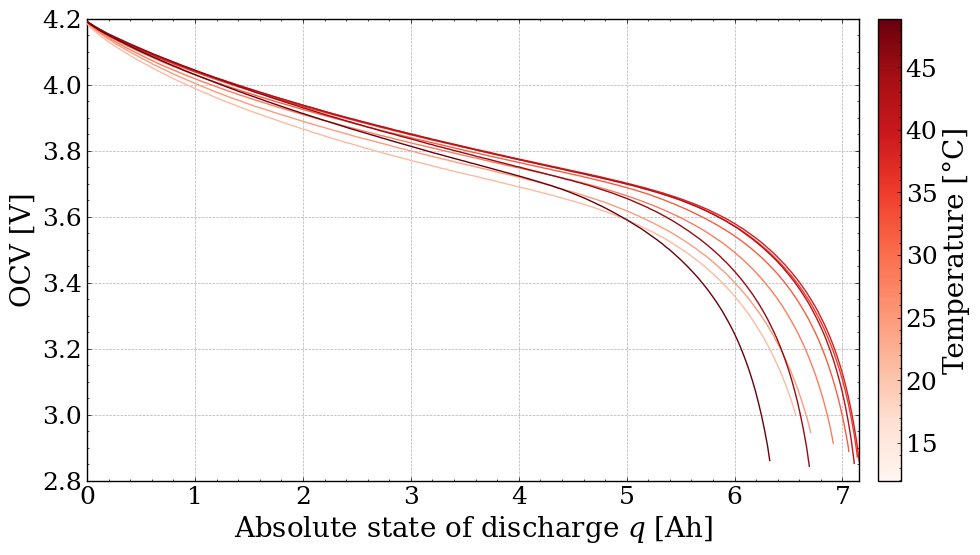

In [5]:
colors = plt.cm.Reds(np.linspace(0.25, 1.0, M))

fig = plt.figure(figsize=(12,6))

for i in range(M):
    q = q_vec[0][i]
    Voc = V_vec[0][i]
    T_avg = T_avg_vec[0][i]
    
    plt.plot(q, Voc, color=colors[i], zorder=10)
    
plt.ylabel('OCV [V]')
plt.xlabel(r'Absolute state of discharge $q$ [Ah]')
plt.margins(0)
plt.ylim(2.8, 4.2)
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=mpl.colors.Normalize(T_avg_vec[0][0], T_avg_vec[0][-1]), cmap='Reds'),
                    orientation='vertical', label='Temperature [°C]', pad=0.02, ax=plt.gca())

## Dataframe creation

In [6]:
df_list = []

for i in range(M): 
    q = q_vec[0][i]
    Voc = V_vec[0][i]
    T = T_vec[0][i]
    T_avg = T_avg_vec[0][i]
    assert(q.shape[0] == Voc.shape[0])
    
    idx_at_V_min = np.argmin(np.abs(Voc - V_min))#np.argmax(Voc < V_min)
    
    tmp = pd.DataFrame(data=0.0, index=range(idx_at_V_min+1), columns=['Curve_id', 'q', 'V_oc', 'T', 'T_avg', 'q(V_min)'])
    tmp['Curve_id'] = i
    tmp['q'] = q[:idx_at_V_min+1]
    tmp['V_oc'] = Voc[:idx_at_V_min+1]
    tmp['T'] = T[:idx_at_V_min+1]
    tmp['T_avg'] = T_avg
    tmp['q(V_min)'] = q[idx_at_V_min].item()
    
    df_list.append(tmp)

df = pd.concat(df_list, ignore_index=True)

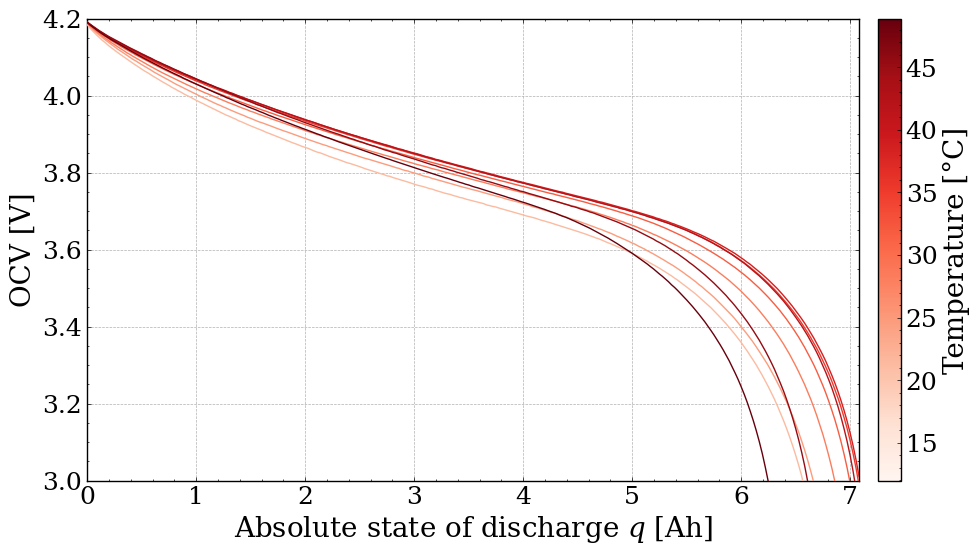

In [7]:
colors = plt.cm.Reds(np.linspace(0.25, 1.0, M))

fig = plt.figure(figsize=(12,6))

for i in range(M):
    tmp = df[df['Curve_id'] == i].copy()
    q = tmp['q'].values
    Voc = tmp['V_oc'].values
    T_avg = tmp['T_avg'].unique().item()
    
    plt.plot(q, Voc, color=colors[i], zorder=10)
    
plt.ylabel('OCV [V]')
plt.xlabel(r'Absolute state of discharge $q$ [Ah]')
plt.margins(0.0)
plt.ylim(3.0, 4.2)
#plt.xlim(0, 7.25)
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=mpl.colors.Normalize(T_avg_vec[0][0], T_avg_vec[0][-1]), cmap='Reds'),
                    orientation='vertical', label='Temperature [°C]', pad=0.02, ax=plt.gca())

In [8]:
# FIG_SIZE = (12,6)
# SAVE_FIG = True
# FIG_FMT = 'pdf'
# TRANSPARENT_PNG=True

# save_fig(
#     fig,
#     'dataset',
#     fig_dir=os.path.join('..','figures'),
#     fig_fmt=FIG_FMT,
#     save=SAVE_FIG, 
#     fig_size=FIG_SIZE,
#     transparent_png=TRANSPARENT_PNG,
# )

## Partial Dependence Plot (PDP)

In [9]:
train = df.copy()
index_cols = ['Curve_id']
features = ['V_oc', 'T_avg']

In [10]:
train['fold'] = -1

LOGO = LeaveOneGroupOut()

for n_fold, (train_fold_idx, valid_fold_idx) in enumerate(LOGO.split(X=train[features], y=train[TARGET], groups=train['Curve_id'])):
    train.loc[valid_fold_idx, 'fold'] = n_fold

In [12]:
config = {
    'model_params': {
        'nfeatures': 2,
        'ntargets': 1,
        'nlayers': 10,
        'hidden_size': 100
    },
    'optimizer_params': {
        'lr': 1e-4,
    },
    'scheduler_params': {
        'mode': 'min',
        'factor': 0.9,
        'patience': 10,
        'threshold': 0.01,
        'verbose': True
    },
    'early_stopping_params': {
        'patience': 20,
        'verbose': False,
        'save_model': False,
    },
    'training_params': {
        'seed': SEED,
        'device': DEVICE,
        'epochs': EPOCHS,
        'batch_size': 16,
        'verbose': True,
        'use_early_stopping': True,
        'fold_column': 'fold'
    }
}

Fold 0 Epoch 0: Train Loss: 0.9859, Valid Loss: 0.8007, Train Eval: 41.7141, Valid Eval: 45.4463
Fold 0 Epoch 1: Train Loss: 0.2002, Valid Loss: 0.0247, Train Eval: 7.8602, Valid Eval: 4.4865
Fold 0 Epoch 2: Train Loss: 0.0101, Valid Loss: 0.0155, Train Eval: 9.3055, Valid Eval: 7.0035
Fold 0 Epoch 3: Train Loss: 0.0073, Valid Loss: 0.0111, Train Eval: 8.5431, Valid Eval: 6.1125
Fold 0 Epoch 4: Train Loss: 0.0050, Valid Loss: 0.0069, Train Eval: 7.5235, Valid Eval: 5.1745
Fold 0 Epoch 5: Train Loss: 0.0025, Valid Loss: 0.0040, Train Eval: 4.7646, Valid Eval: 2.6978
Fold 0 Epoch 6: Train Loss: 0.0012, Valid Loss: 0.0031, Train Eval: 3.6895, Valid Eval: 1.8300
Fold 0 Epoch 7: Train Loss: 0.0008, Valid Loss: 0.0028, Train Eval: 3.2638, Valid Eval: 1.7224
Fold 0 Epoch 8: Train Loss: 0.0007, Valid Loss: 0.0022, Train Eval: 2.9623, Valid Eval: 1.3730
Fold 0 Epoch 9: Train Loss: 0.0004, Valid Loss: 0.0029, Train Eval: 2.4659, Valid Eval: 1.3133
Fold 0 Epoch 10: Train Loss: 0.0003, Valid Loss:

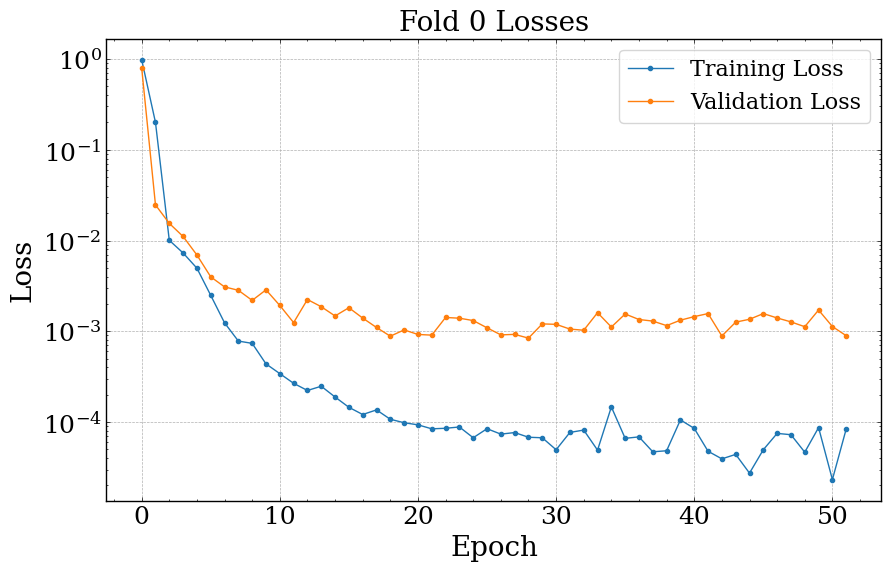

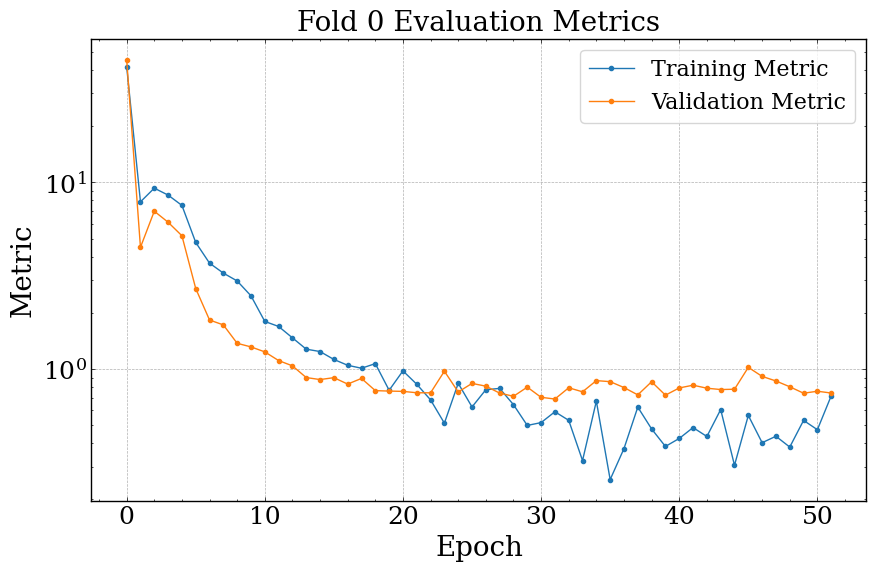

Fold 1 Epoch 0: Train Loss: 0.9802, Valid Loss: 0.7882, Train Eval: 40.5865, Valid Eval: 43.9692
Fold 1 Epoch 1: Train Loss: 0.2059, Valid Loss: 0.0303, Train Eval: 10.4827, Valid Eval: 7.6542
Fold 1 Epoch 2: Train Loss: 0.0108, Valid Loss: 0.0064, Train Eval: 8.3871, Valid Eval: 5.1811
Fold 1 Epoch 3: Train Loss: 0.0069, Valid Loss: 0.0076, Train Eval: 7.1933, Valid Eval: 3.5620
Fold 1 Epoch 4: Train Loss: 0.0039, Valid Loss: 0.0029, Train Eval: 5.8930, Valid Eval: 3.2801
Fold 1 Epoch 5: Train Loss: 0.0020, Valid Loss: 0.0017, Train Eval: 3.3207, Valid Eval: 1.4597
Fold 1 Epoch 6: Train Loss: 0.0011, Valid Loss: 0.0010, Train Eval: 3.7001, Valid Eval: 1.8672
Fold 1 Epoch 7: Train Loss: 0.0009, Valid Loss: 0.0005, Train Eval: 2.9657, Valid Eval: 1.1015
Fold 1 Epoch 8: Train Loss: 0.0007, Valid Loss: 0.0004, Train Eval: 2.5495, Valid Eval: 0.9515
Fold 1 Epoch 9: Train Loss: 0.0005, Valid Loss: 0.0005, Train Eval: 2.5802, Valid Eval: 0.9469
Fold 1 Epoch 10: Train Loss: 0.0004, Valid Loss

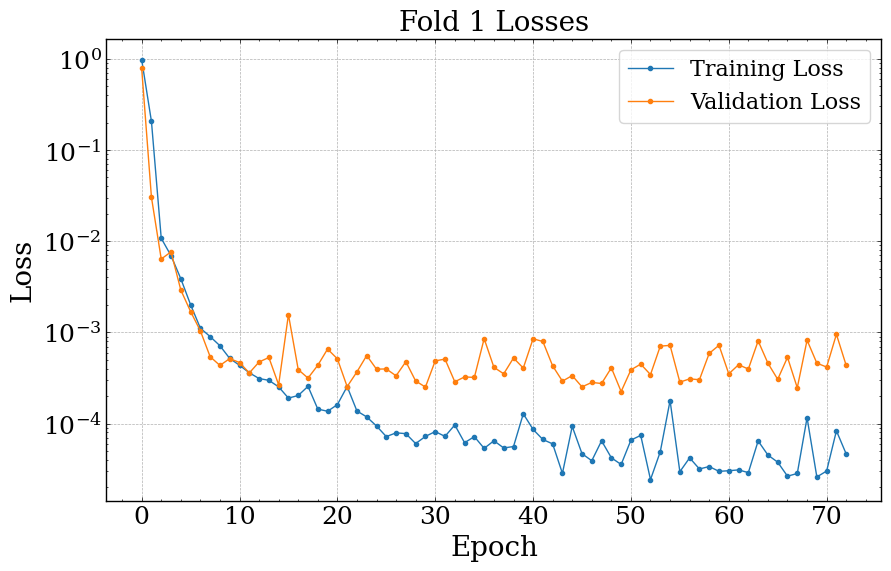

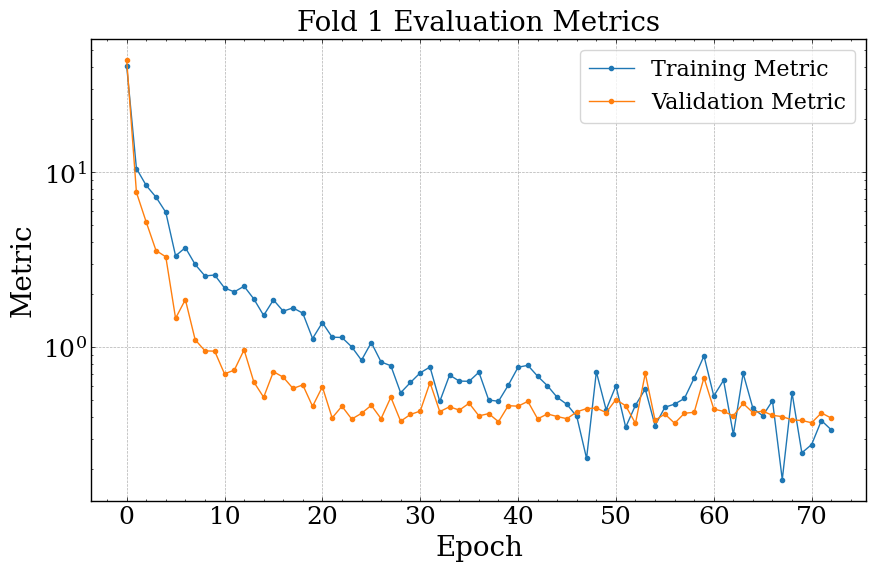

Fold 2 Epoch 0: Train Loss: 0.9813, Valid Loss: 0.8674, Train Eval: 41.1538, Valid Eval: 44.2783
Fold 2 Epoch 1: Train Loss: 0.1965, Valid Loss: 0.0041, Train Eval: 8.7581, Valid Eval: 4.7364
Fold 2 Epoch 2: Train Loss: 0.0106, Valid Loss: 0.0023, Train Eval: 7.4042, Valid Eval: 3.1656
Fold 2 Epoch 3: Train Loss: 0.0061, Valid Loss: 0.0010, Train Eval: 6.4976, Valid Eval: 2.8211
Fold 2 Epoch 4: Train Loss: 0.0032, Valid Loss: 0.0008, Train Eval: 4.7246, Valid Eval: 2.2040
Fold 2 Epoch 5: Train Loss: 0.0015, Valid Loss: 0.0006, Train Eval: 3.5003, Valid Eval: 1.3943
Fold 2 Epoch 6: Train Loss: 0.0010, Valid Loss: 0.0006, Train Eval: 2.9285, Valid Eval: 0.8837
Fold 2 Epoch 7: Train Loss: 0.0007, Valid Loss: 0.0005, Train Eval: 2.5042, Valid Eval: 1.0140
Fold 2 Epoch 8: Train Loss: 0.0006, Valid Loss: 0.0005, Train Eval: 2.2162, Valid Eval: 0.9063
Fold 2 Epoch 9: Train Loss: 0.0006, Valid Loss: 0.0003, Train Eval: 1.9536, Valid Eval: 0.7804
Fold 2 Epoch 10: Train Loss: 0.0004, Valid Loss:

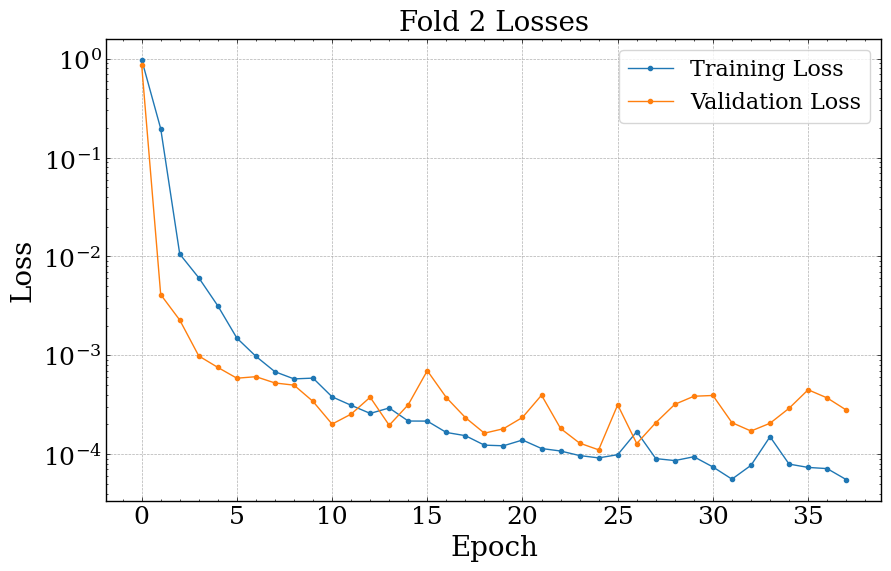

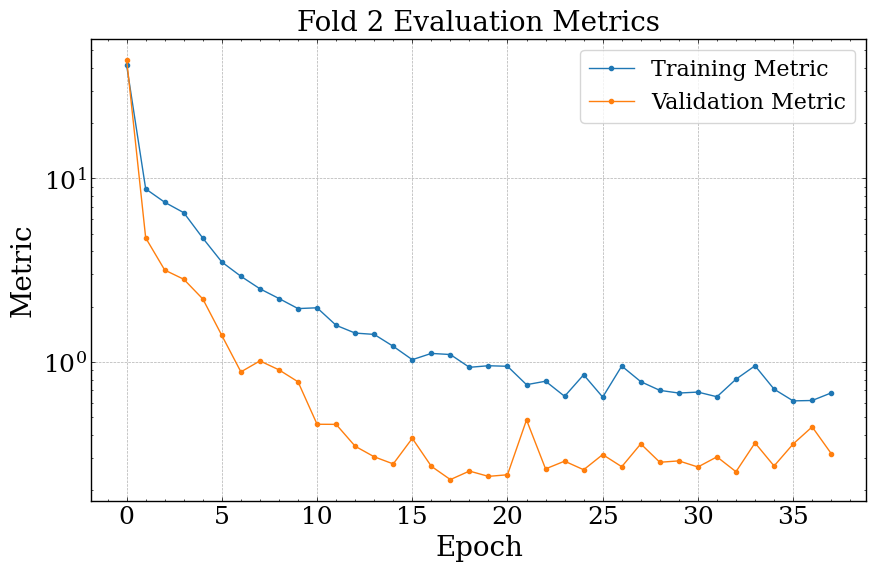

Fold 3 Epoch 0: Train Loss: 0.9826, Valid Loss: 0.9253, Train Eval: 41.3727, Valid Eval: 44.4954
Fold 3 Epoch 1: Train Loss: 0.2085, Valid Loss: 0.0203, Train Eval: 8.3371, Valid Eval: 4.8859
Fold 3 Epoch 2: Train Loss: 0.0117, Valid Loss: 0.0100, Train Eval: 7.9586, Valid Eval: 3.3950
Fold 3 Epoch 3: Train Loss: 0.0075, Valid Loss: 0.0027, Train Eval: 8.1977, Valid Eval: 2.8576
Fold 3 Epoch 4: Train Loss: 0.0039, Valid Loss: 0.0024, Train Eval: 6.0521, Valid Eval: 1.9927
Fold 3 Epoch 5: Train Loss: 0.0018, Valid Loss: 0.0011, Train Eval: 4.1732, Valid Eval: 0.9413
Fold 3 Epoch 6: Train Loss: 0.0012, Valid Loss: 0.0010, Train Eval: 3.3958, Valid Eval: 0.7660
Fold 3 Epoch 7: Train Loss: 0.0013, Valid Loss: 0.0007, Train Eval: 3.0327, Valid Eval: 0.5807
Fold 3 Epoch 8: Train Loss: 0.0008, Valid Loss: 0.0010, Train Eval: 2.8175, Valid Eval: 0.7445
Fold 3 Epoch 9: Train Loss: 0.0007, Valid Loss: 0.0005, Train Eval: 2.6339, Valid Eval: 0.5366
Fold 3 Epoch 10: Train Loss: 0.0005, Valid Loss:

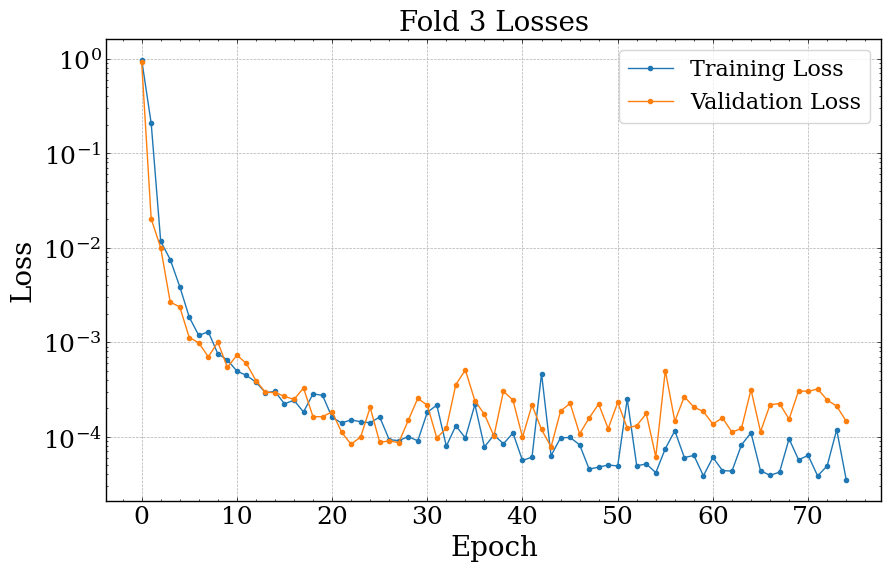

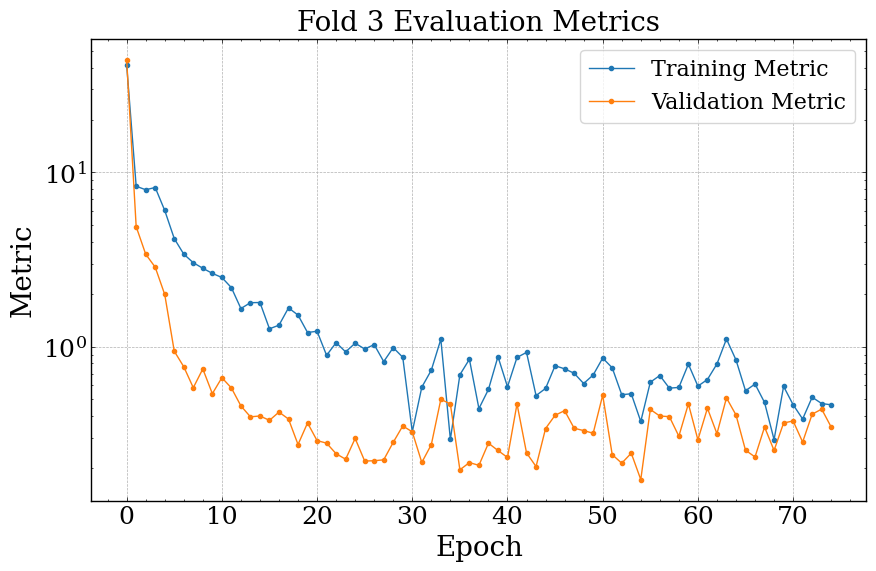

Fold 4 Epoch 0: Train Loss: 0.9845, Valid Loss: 0.9648, Train Eval: 41.9431, Valid Eval: 45.1378
Fold 4 Epoch 1: Train Loss: 0.2053, Valid Loss: 0.0212, Train Eval: 9.8269, Valid Eval: 5.6252
Fold 4 Epoch 2: Train Loss: 0.0106, Valid Loss: 0.0156, Train Eval: 7.7104, Valid Eval: 2.6429
Fold 4 Epoch 3: Train Loss: 0.0068, Valid Loss: 0.0065, Train Eval: 7.7233, Valid Eval: 2.1994
Fold 4 Epoch 4: Train Loss: 0.0044, Valid Loss: 0.0025, Train Eval: 6.2621, Valid Eval: 1.3821
Fold 4 Epoch 5: Train Loss: 0.0023, Valid Loss: 0.0015, Train Eval: 3.7862, Valid Eval: 0.8940
Fold 4 Epoch 6: Train Loss: 0.0016, Valid Loss: 0.0009, Train Eval: 3.2525, Valid Eval: 0.7491
Fold 4 Epoch 7: Train Loss: 0.0010, Valid Loss: 0.0006, Train Eval: 2.8913, Valid Eval: 0.9463
Fold 4 Epoch 8: Train Loss: 0.0008, Valid Loss: 0.0003, Train Eval: 2.9648, Valid Eval: 0.5329
Fold 4 Epoch 9: Train Loss: 0.0007, Valid Loss: 0.0008, Train Eval: 2.8323, Valid Eval: 0.4145
Fold 4 Epoch 10: Train Loss: 0.0006, Valid Loss:

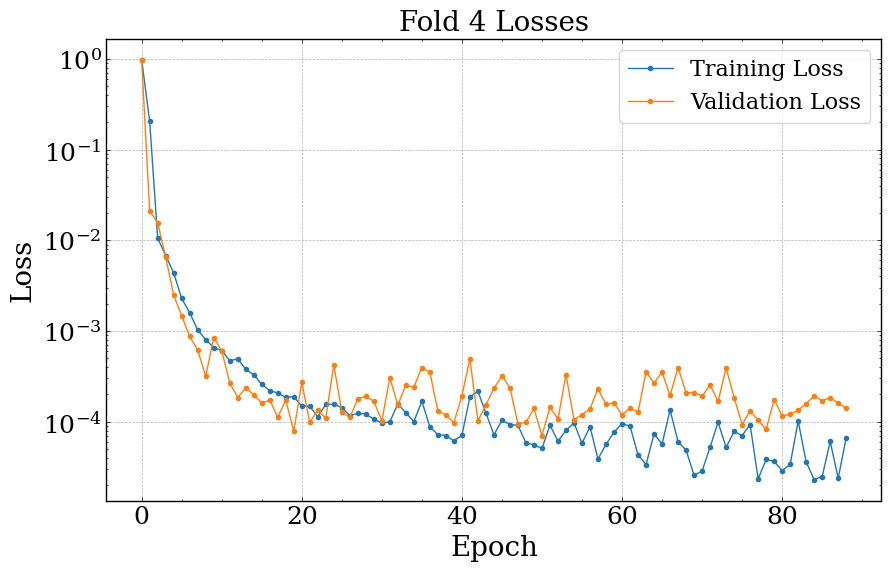

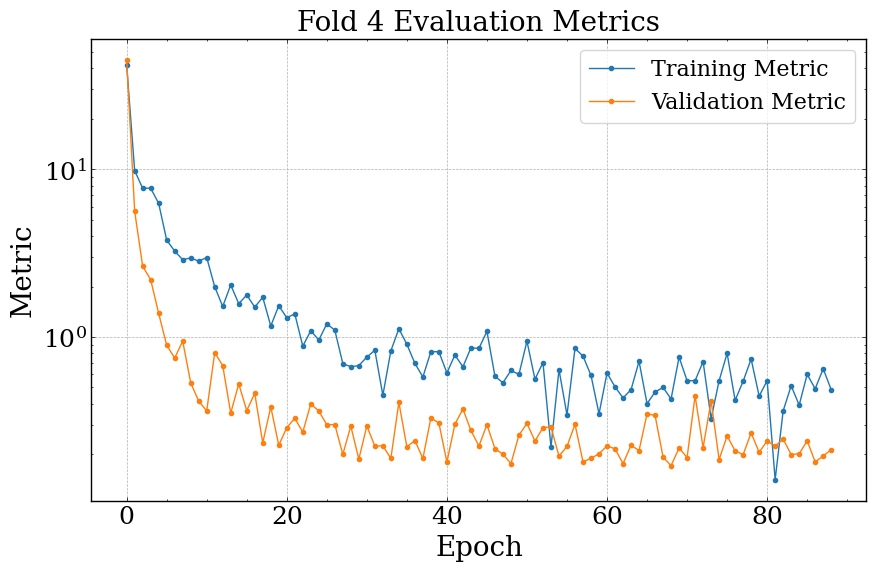

Fold 5 Epoch 0: Train Loss: 0.9863, Valid Loss: 0.9752, Train Eval: 42.1997, Valid Eval: 45.4314
Fold 5 Epoch 1: Train Loss: 0.2101, Valid Loss: 0.0203, Train Eval: 9.6071, Valid Eval: 4.6218
Fold 5 Epoch 2: Train Loss: 0.0106, Valid Loss: 0.0181, Train Eval: 7.6087, Valid Eval: 2.5572
Fold 5 Epoch 3: Train Loss: 0.0067, Valid Loss: 0.0064, Train Eval: 7.5413, Valid Eval: 1.7533
Fold 5 Epoch 4: Train Loss: 0.0039, Valid Loss: 0.0023, Train Eval: 5.7491, Valid Eval: 0.9520
Fold 5 Epoch 5: Train Loss: 0.0020, Valid Loss: 0.0023, Train Eval: 3.5056, Valid Eval: 1.3098
Fold 5 Epoch 6: Train Loss: 0.0015, Valid Loss: 0.0016, Train Eval: 3.0212, Valid Eval: 1.3683
Fold 5 Epoch 7: Train Loss: 0.0010, Valid Loss: 0.0011, Train Eval: 2.7263, Valid Eval: 1.4275
Fold 5 Epoch 8: Train Loss: 0.0008, Valid Loss: 0.0006, Train Eval: 2.7731, Valid Eval: 0.9148
Fold 5 Epoch 9: Train Loss: 0.0006, Valid Loss: 0.0015, Train Eval: 2.7216, Valid Eval: 0.7641
Fold 5 Epoch 10: Train Loss: 0.0006, Valid Loss:

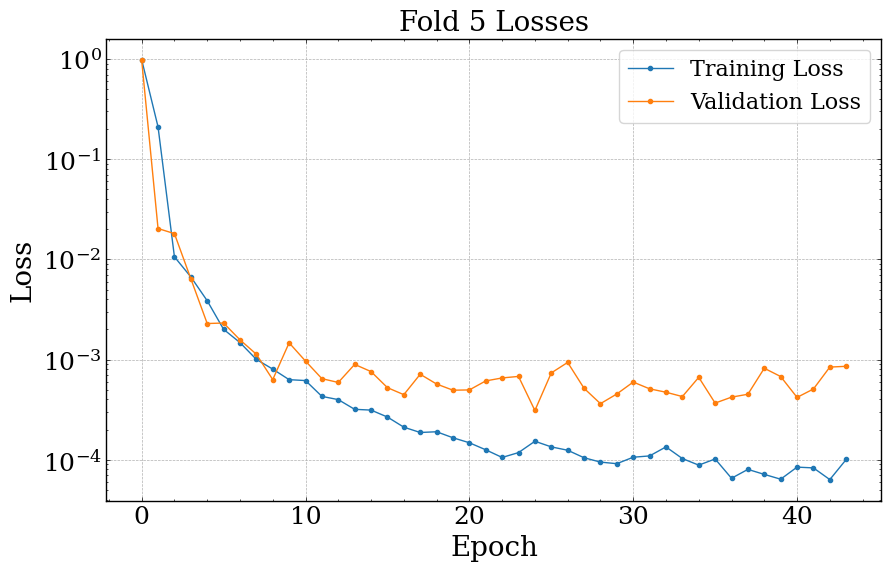

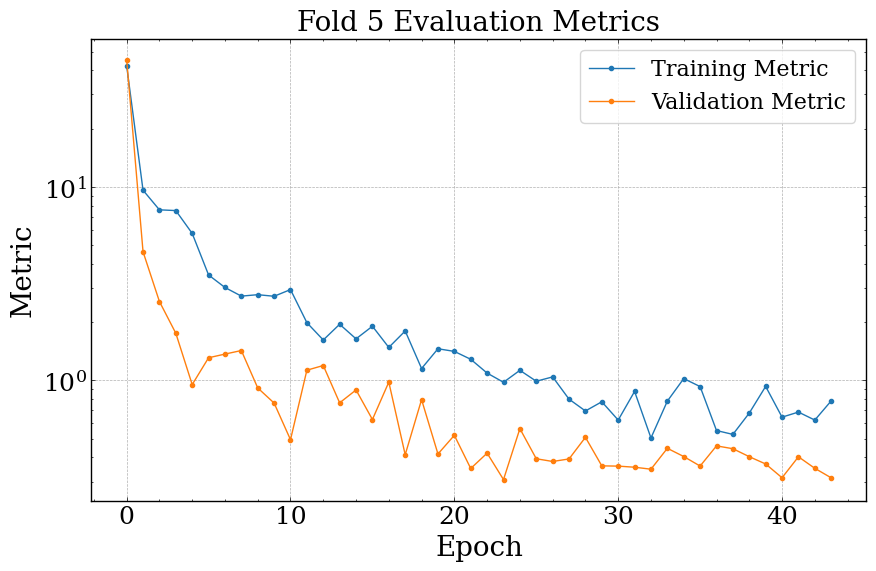

Fold 6 Epoch 0: Train Loss: 0.9793, Valid Loss: 0.9290, Train Eval: 40.8286, Valid Eval: 44.2685
Fold 6 Epoch 1: Train Loss: 0.1952, Valid Loss: 0.0214, Train Eval: 7.9791, Valid Eval: 4.3954
Fold 6 Epoch 2: Train Loss: 0.0100, Valid Loss: 0.0117, Train Eval: 8.2103, Valid Eval: 3.8535
Fold 6 Epoch 3: Train Loss: 0.0061, Valid Loss: 0.0085, Train Eval: 6.2110, Valid Eval: 2.5083
Fold 6 Epoch 4: Train Loss: 0.0029, Valid Loss: 0.0035, Train Eval: 5.3992, Valid Eval: 1.7925
Fold 6 Epoch 5: Train Loss: 0.0019, Valid Loss: 0.0064, Train Eval: 3.6586, Valid Eval: 1.0083
Fold 6 Epoch 6: Train Loss: 0.0011, Valid Loss: 0.0060, Train Eval: 3.2625, Valid Eval: 0.7733
Fold 6 Epoch 7: Train Loss: 0.0008, Valid Loss: 0.0044, Train Eval: 2.7141, Valid Eval: 0.9024
Fold 6 Epoch 8: Train Loss: 0.0007, Valid Loss: 0.0045, Train Eval: 2.4375, Valid Eval: 1.0540
Fold 6 Epoch 9: Train Loss: 0.0006, Valid Loss: 0.0052, Train Eval: 2.1949, Valid Eval: 0.8303
Fold 6 Epoch 10: Train Loss: 0.0005, Valid Loss:

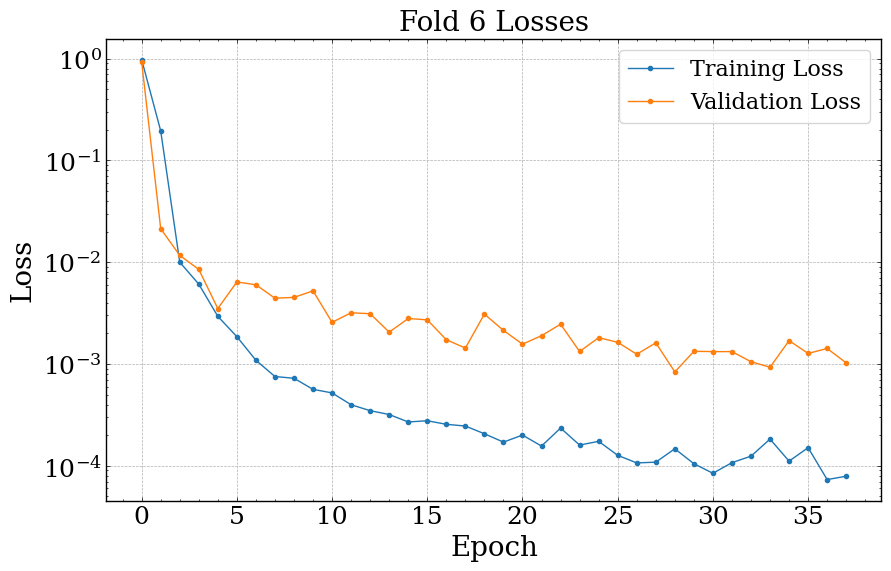

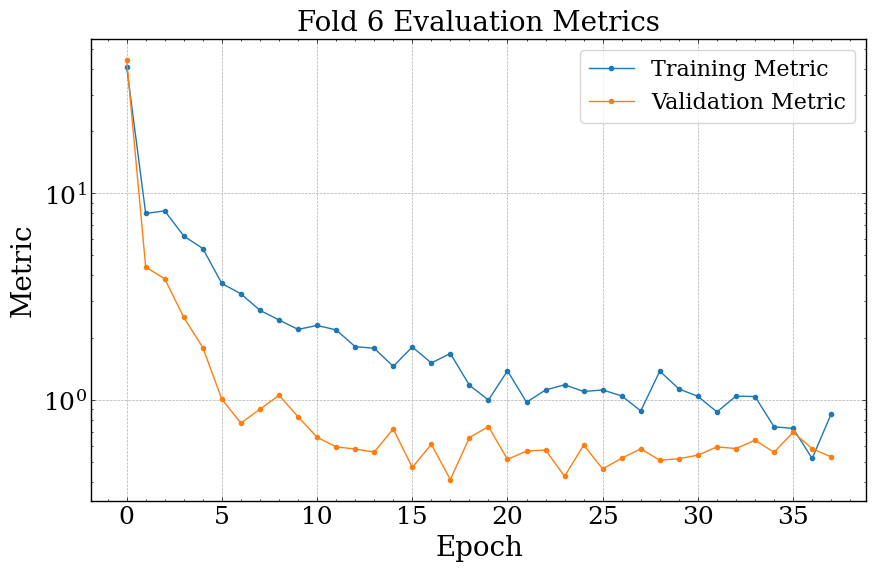

Fold 7 Epoch 0: Train Loss: 0.9796, Valid Loss: 0.7831, Train Eval: 40.5299, Valid Eval: 44.1429
Fold 7 Epoch 1: Train Loss: 0.1983, Valid Loss: 0.0026, Train Eval: 8.4927, Valid Eval: 4.6662
Fold 7 Epoch 2: Train Loss: 0.0120, Valid Loss: 0.0064, Train Eval: 9.9095, Valid Eval: 6.3773
Fold 7 Epoch 3: Train Loss: 0.0079, Valid Loss: 0.0026, Train Eval: 7.9557, Valid Eval: 4.8137
Fold 7 Epoch 4: Train Loss: 0.0046, Valid Loss: 0.0043, Train Eval: 7.5682, Valid Eval: 5.2287
Fold 7 Epoch 5: Train Loss: 0.0025, Valid Loss: 0.0035, Train Eval: 6.5560, Valid Eval: 4.4113
Fold 7 Epoch 6: Train Loss: 0.0019, Valid Loss: 0.0015, Train Eval: 4.7068, Valid Eval: 2.7964
Fold 7 Epoch 7: Train Loss: 0.0013, Valid Loss: 0.0021, Train Eval: 3.8752, Valid Eval: 2.2087
Fold 7 Epoch 8: Train Loss: 0.0011, Valid Loss: 0.0007, Train Eval: 3.8019, Valid Eval: 2.0517
Fold 7 Epoch 9: Train Loss: 0.0007, Valid Loss: 0.0003, Train Eval: 3.0198, Valid Eval: 1.5904
Fold 7 Epoch 10: Train Loss: 0.0007, Valid Loss:

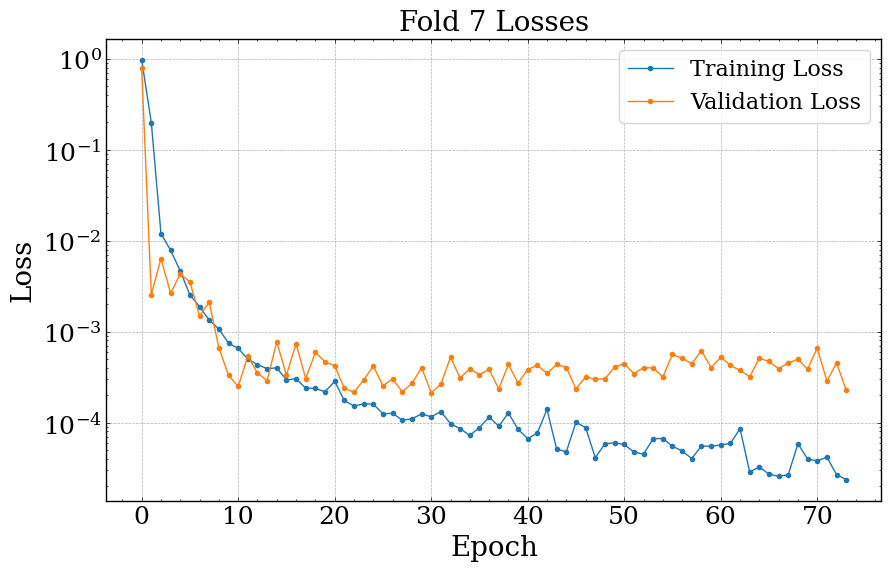

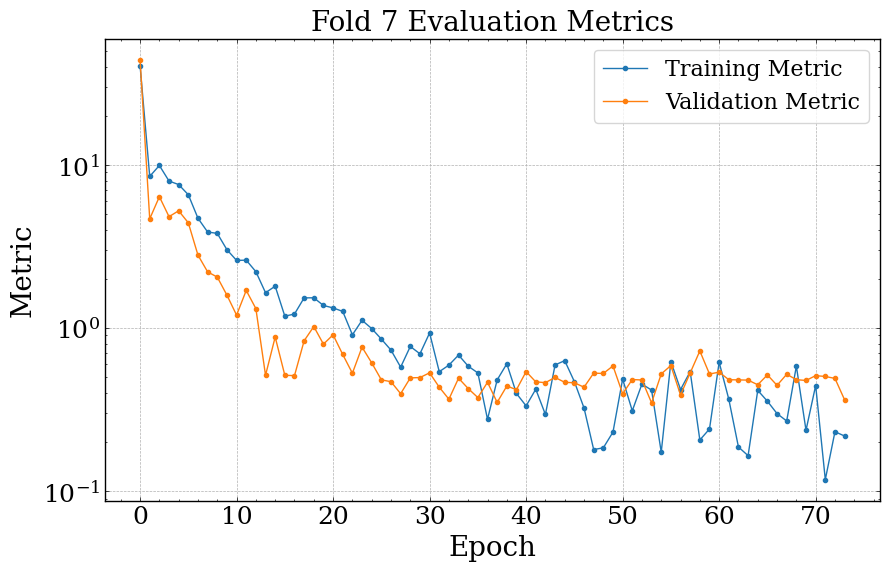

Fold 8 Epoch 0: Train Loss: 0.9841, Valid Loss: 0.7353, Train Eval: 43.3812, Valid Eval: 45.0872
Fold 8 Epoch 1: Train Loss: 0.1946, Valid Loss: 0.0350, Train Eval: 7.7388, Valid Eval: 7.8338
Fold 8 Epoch 2: Train Loss: 0.0082, Valid Loss: 0.0347, Train Eval: 7.0377, Valid Eval: 6.9841
Fold 8 Epoch 3: Train Loss: 0.0054, Valid Loss: 0.0270, Train Eval: 6.4565, Valid Eval: 6.7381
Fold 8 Epoch 4: Train Loss: 0.0036, Valid Loss: 0.0243, Train Eval: 6.0805, Valid Eval: 6.3166
Fold 8 Epoch 5: Train Loss: 0.0024, Valid Loss: 0.0208, Train Eval: 5.1698, Valid Eval: 5.5036
Fold 8 Epoch 6: Train Loss: 0.0017, Valid Loss: 0.0126, Train Eval: 3.5903, Valid Eval: 3.6967
Fold 8 Epoch 7: Train Loss: 0.0013, Valid Loss: 0.0181, Train Eval: 3.7218, Valid Eval: 3.6894
Fold 8 Epoch 8: Train Loss: 0.0010, Valid Loss: 0.0085, Train Eval: 3.2888, Valid Eval: 3.8459
Fold 8 Epoch 9: Train Loss: 0.0008, Valid Loss: 0.0053, Train Eval: 2.6901, Valid Eval: 3.1566
Fold 8 Epoch 10: Train Loss: 0.0007, Valid Loss:

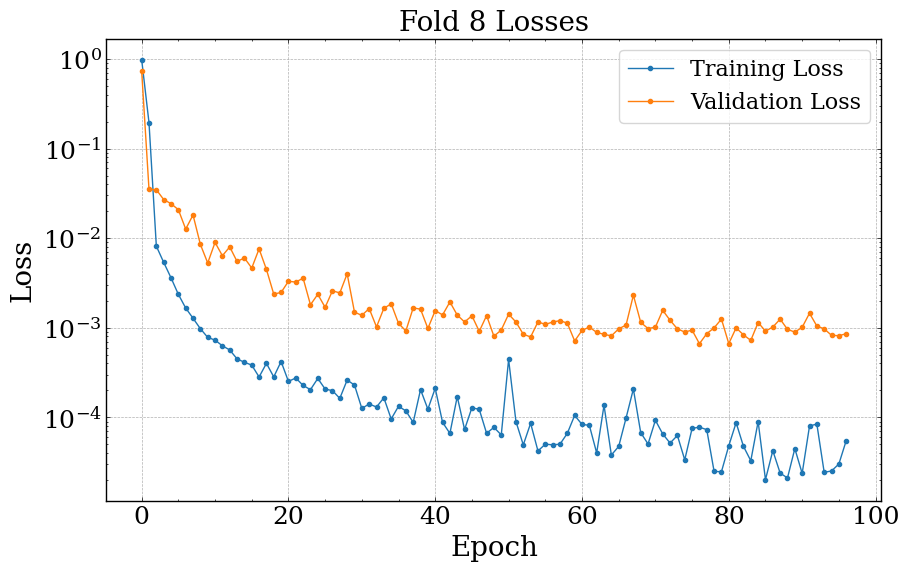

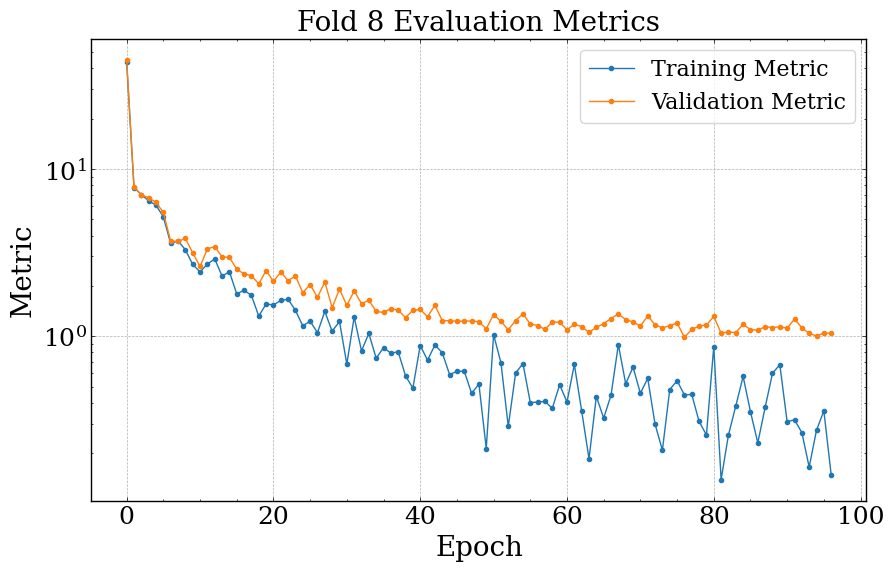

In [13]:
results = []
for fold in range(LOGO.get_n_splits(groups=train['Curve_id'])):
    result = run_training(train=train,
                          features=features,
                          target=TARGET,
                          fold=fold,
                          config=config)
    # Plot training and validation losses
    plt.figure(figsize=(10, 6))  # Optionally specify the figure size
    plt.plot(result['train_losses'], '.-', label='Training Loss')
    plt.plot(result['valid_losses'], '.-', label='Validation Loss')
    plt.yscale('log')
    plt.title(f'Fold {fold} Losses')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot training and validation evaluation metrics
    plt.figure(figsize=(10, 6))
    plt.plot(result['train_eval_metrics'], '.-', label='Training Metric')
    plt.plot(result['valid_eval_metrics'], '.-', label='Validation Metric')
    plt.yscale('log')
    plt.title(f'Fold {fold} Evaluation Metrics')
    plt.xlabel('Epoch')
    plt.ylabel('Metric')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    results.append(result)

In [26]:
# Setup based on configuration
seed = SEED
device = DEVICE
epochs = np.median([results[i]['stopping_round'] for i in range(len(results))]).astype(int)
batch_size = 16
verbose = True
use_early_stopping = False
fold_column = 'fold'
target = TARGET

# Seed and prepare data splits
seed_everything(seed=seed)

train_x = train[features].to_numpy()
train_y = train[target].to_numpy().reshape(-1,1)

# Scale features and targets
scaler_x, scaler_y = StandardScaler(), StandardScaler()
train_x, train_y  = scaler_x.fit_transform(train_x), scaler_y.fit_transform(train_y)

# Convert to torch tensors and move to device
train_x = torch.from_numpy(train_x).type(torch.Tensor).to(device)
train_y = torch.from_numpy(train_y).type(torch.Tensor).to(device)

# Create data loaders
train_dataset = TensorDataset(train_x, train_y)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False)

In [27]:
# Initialize model, optimizer, and engine
model = FeedForwardNN(**config['model_params'])
model.to(device)
optimizer = torch.optim.Adam(model.parameters(), **config['optimizer_params'])
eng = Engine(model=model, optimizer=optimizer, loss_fn=nn.MSELoss())
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,  **config['scheduler_params'])

In [28]:
# Training and validation loops
train_losses = []
train_eval_metrics = []

for epoch in range(epochs):
    train_loss = 0.0
    train_samples = 0
    for train_fold_x_batch, train_fold_y_batch in train_loader:
        train_loss_batch, train_preds_batch = eng.train(train_fold_x_batch, train_fold_y_batch)
        train_loss += train_loss_batch * train_fold_x_batch.size(0)
        train_samples += train_fold_x_batch.size(0)
    train_loss /= train_samples

    train_losses.append(train_loss)

    model.eval()
    with torch.no_grad():
        train_preds = scaler_y.inverse_transform(model(train_x).cpu().numpy())
        train_eval_metric = eval_metric(train[target].to_numpy(), train_preds)
    
    train_eval_metrics.append(train_eval_metric)

    if (verbose) and (epoch % 1 == 0):
        print(f"Fold {fold} Epoch {epoch}: Train Loss: {train_loss:.4f}, Train Eval: {train_eval_metric:.4f}")

Fold 8 Epoch 0: Train Loss: 0.9557, Train Eval: 31.4513
Fold 8 Epoch 1: Train Loss: 0.0767, Train Eval: 9.4901
Fold 8 Epoch 2: Train Loss: 0.0095, Train Eval: 8.4963
Fold 8 Epoch 3: Train Loss: 0.0052, Train Eval: 7.2432
Fold 8 Epoch 4: Train Loss: 0.0029, Train Eval: 5.1184
Fold 8 Epoch 5: Train Loss: 0.0017, Train Eval: 3.7810
Fold 8 Epoch 6: Train Loss: 0.0010, Train Eval: 3.3753
Fold 8 Epoch 7: Train Loss: 0.0008, Train Eval: 2.9311
Fold 8 Epoch 8: Train Loss: 0.0006, Train Eval: 2.5862
Fold 8 Epoch 9: Train Loss: 0.0005, Train Eval: 2.2876
Fold 8 Epoch 10: Train Loss: 0.0004, Train Eval: 2.3746
Fold 8 Epoch 11: Train Loss: 0.0003, Train Eval: 2.1920
Fold 8 Epoch 12: Train Loss: 0.0003, Train Eval: 1.8424
Fold 8 Epoch 13: Train Loss: 0.0003, Train Eval: 1.5738
Fold 8 Epoch 14: Train Loss: 0.0002, Train Eval: 1.9691
Fold 8 Epoch 15: Train Loss: 0.0002, Train Eval: 1.5585
Fold 8 Epoch 16: Train Loss: 0.0002, Train Eval: 1.5566
Fold 8 Epoch 17: Train Loss: 0.0002, Train Eval: 1.4904
F

In [29]:
nox_values = np.linspace(np.min(X['NOX']), np.max(X['NOX']))

pdp_values = []
for n in nox_values:
  X_pdp = X.copy()
  X_pdp['NOX'] = n
  pdp_values.append(np.mean(rf_model.predict(X_pdp)))

FeedForwardNN(
  (layers): ModuleList(
    (0): Linear(in_features=2, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=100, bias=True)
    (5): ReLU()
    (6): Linear(in_features=100, out_features=100, bias=True)
    (7): ReLU()
    (8): Linear(in_features=100, out_features=100, bias=True)
    (9): ReLU()
    (10): Linear(in_features=100, out_features=100, bias=True)
    (11): ReLU()
    (12): Linear(in_features=100, out_features=100, bias=True)
    (13): ReLU()
    (14): Linear(in_features=100, out_features=100, bias=True)
    (15): ReLU()
    (16): Linear(in_features=100, out_features=100, bias=True)
    (17): ReLU()
    (18): Linear(in_features=100, out_features=100, bias=True)
    (19): ReLU()
    (20): Linear(in_features=100, out_features=1, bias=True)
  )
)

tensor(-1.4936, device='cuda:1')

In [132]:
T_avg_grid = np.linspace(train.iloc[0]['T_avg'], train.iloc[-1]['T_avg'], 1000)

T_avg_grid = np.linspace(0, 60, 1000)

pdp_values_mean = []
pdp_values_quantile_25 = []
pdp_values_quantile_75 = []

for T_avg in T_avg_grid:
    train_x_tmp = torch.clone(train_x)
    train_x_tmp[:,1] = torch.from_numpy(scaler_x.transform(np.array([0, T_avg], ndmin=2))[:,1]).type(torch.Tensor).to(device)
    train_preds = model(train_x_tmp)
    pdp_values_quantile_25.append(torch.quantile(train_preds, 0.25).item())
    pdp_values_mean.append(torch.mean(train_preds[-1]).item())
    pdp_values_quantile_75.append(torch.quantile(train_preds, 0.75).item())

pdp_values_quantile_25 = scaler_y.inverse_transform(np.array(pdp_values_quantile_25).reshape(-1,1))
pdp_values_mean = scaler_y.inverse_transform(np.array(pdp_values_mean).reshape(-1,1))
pdp_values_quantile_75 = scaler_y.inverse_transform(np.array(pdp_values_quantile_75).reshape(-1,1))

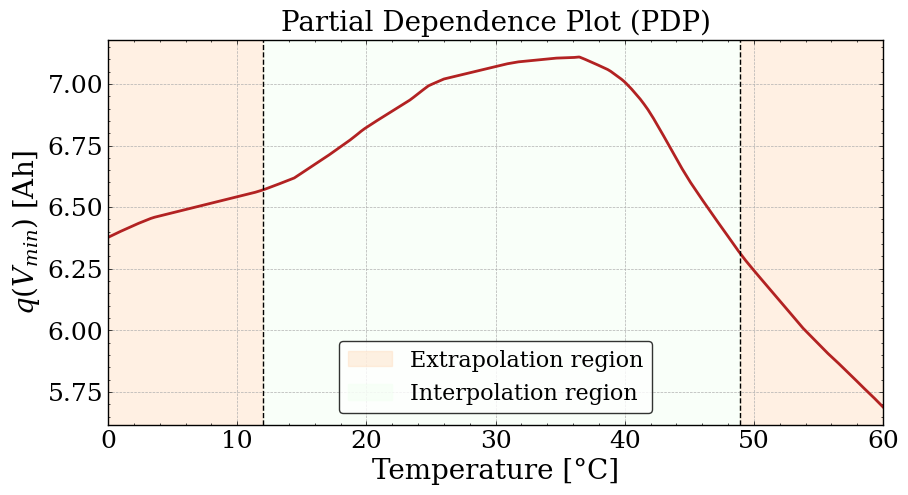

In [141]:
import matplotlib.patches as mpatches

# Create the plot
plt.figure(figsize=(10, 5))
plt.plot(T_avg_grid, pdp_values_mean,
         #label='PDP values',
         linewidth=2, color='firebrick')
#plt.fill_between(T_avg_grid, pdp_values_quantile_25.flatten(), pdp_values_quantile_75.flatten(), color='firebrick', alpha=0.3, label='90% Confidence Interval')

plt.axvline(train.iloc[0]['T_avg'], linestyle='--', color='k', label='Train distribution bounds')
plt.axvline(train.iloc[-1]['T_avg'], linestyle='--', color='k')

extrapolation_patch = mpatches.Patch(color='peachpuff', alpha=0.4, edgecolor='black', label='Extrapolation region')
interpolation_patch = mpatches.Patch(color='honeydew', alpha=0.4, edgecolor='black', label='Interpolation region')

# Fill outside the axvlines with light orange
plt.axvspan(T_avg_grid[0], train.iloc[0]['T_avg'], color='peachpuff', alpha=0.4, label='Extrapolation region')
plt.axvspan(train.iloc[-1]['T_avg'], T_avg_grid[-1], color='peachpuff', alpha=0.4)

# Fill between the axvlines with light green
plt.axvspan(train.iloc[0]['T_avg'], train.iloc[-1]['T_avg'], color='honeydew', alpha=0.4, label='Interpolation region')

# Enhancements for readability
plt.xlabel('Temperature [°C]')
plt.ylabel(r'$q(V_{min})$ [Ah]')
plt.legend()
plt.title('Partial Dependence Plot (PDP)')
plt.grid(True)
plt.xlim(0,60)
#plt.ylim(2,3.75)

# Create patches for legend with specific edge color
plt.legend(handles=[extrapolation_patch, interpolation_patch], frameon=True, edgecolor='black')


# Show the plot
plt.show()

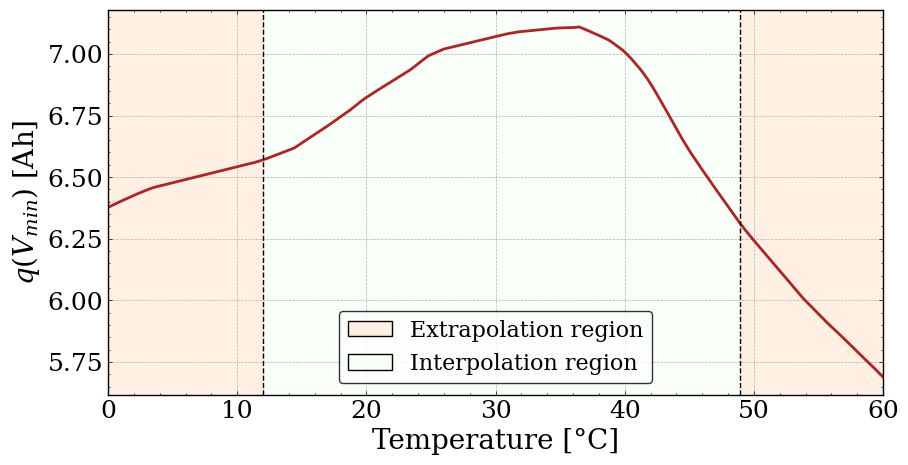

In [147]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerPatch

# Create a custom handler for the legend
class HandlerColoredPatch(HandlerPatch):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        # This function modifies the patch (the handle) by adding a border
        patch = mpatches.Rectangle([xdescent, ydescent], width, height,
                                   facecolor=orig_handle.get_facecolor(),
                                   edgecolor='black', linewidth=1,  # Add border here
                                   transform=trans)
        return [patch]

# Create the plot
fig = plt.figure(figsize=(10, 5))
plt.plot(T_avg_grid, pdp_values_mean,
         linewidth=2, color='firebrick', label='PDP values')

# Vertical lines for train distribution bounds
plt.axvline(train.iloc[0]['T_avg'], linestyle='--', color='k', label='Train distribution bounds')
plt.axvline(train.iloc[-1]['T_avg'], linestyle='--', color='k')

# Fill regions
plt.axvspan(T_avg_grid[0], train.iloc[0]['T_avg'], color='peachpuff', alpha=0.4)
plt.axvspan(train.iloc[-1]['T_avg'], T_avg_grid[-1], color='peachpuff', alpha=0.4)
extrapolation_patch = mpatches.Patch(color='peachpuff', alpha=0.4, label='Extrapolation region')
interpolation_patch = mpatches.Patch(color='honeydew', alpha=0.4, label='Interpolation region')
plt.axvspan(train.iloc[0]['T_avg'], train.iloc[-1]['T_avg'], color='honeydew', alpha=0.4)

# Enhancements for readability
plt.xlabel('Temperature [°C]')
plt.ylabel(r'$q(V_{min})$ [Ah]')
#plt.title('Partial Dependence Plot (PDP)')
plt.grid(True)
plt.xlim(0, 60)

# Legend with custom handler for specific patches
plt.legend(handles=[extrapolation_patch, interpolation_patch],
           handler_map={mpatches.Patch: HandlerColoredPatch()},
           frameon=True, edgecolor='black')
plt.show()

In [145]:
FIG_SIZE = (10, 5)
SAVE_FIG = True
FIG_FMT = 'pdf'
TRANSPARENT_PNG=True

save_fig(
    fig,
    'sensitivity',
    fig_dir=os.path.join('..','figures'),
    fig_fmt=FIG_FMT,
    save=SAVE_FIG, 
    fig_size=FIG_SIZE,
    transparent_png=TRANSPARENT_PNG,
)